In [4]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Embedding, LSTM, Dense, Conv1D, GlobalAveragePooling1D, Bidirectional, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tensorflow.keras.layers import Reshape
import pickle

In [5]:
# Combining fake and real news into a single dataframe
fake_news = pd.read_csv('fake_cleaned.csv')
real_news = pd.read_csv('true_cleaned.csv')

fake_news['label'] = 0  # 0 for fake
real_news['label'] = 1  # 1 for real
data = pd.concat([fake_news, real_news], ignore_index=True)

texts = data['text'].values
labels = data['label'].values

# Tokenization and padding
max_words = 10000
max_len = 200
tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

with open('LSTMs-tokenizer.pkl', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)

In [6]:
# Evaluating models with classification report
def evaluate_model(model, X_test, y_test, bert=False):
    if bert:
        preds = (model.predict([X_test['input_ids'], X_test['attention_mask']]) > 0.5).astype('int32')
    else:
        preds = (model.predict(X_test) > 0.5).astype('int32')
    print(classification_report(y_test, preds))

In [7]:
# Define LSTM model
def build_lstm_model():
    model = Sequential([
        Embedding(max_words, 128, input_length=max_len),
        Bidirectional(LSTM(64, return_sequences=False)),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model


# Define CNN + LSTM model
def build_cnn_lstm_model():
    model = Sequential([
        Embedding(max_words, 128, input_length=max_len),
        Conv1D(64, 5, activation='relu'),
        GlobalAveragePooling1D(),
        Reshape((1, 64)),
        Bidirectional(LSTM(64, return_sequences=False)),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model


In [8]:
lstm_model = build_lstm_model()
lstm_model.fit(X_train, y_train, epochs=5, batch_size=256, validation_data=(X_test, y_test))

Epoch 1/5
138/138 [==============================] - 64s 438ms/step - loss: 0.1287 - accuracy: 0.9407 - val_loss: 0.0070 - val_accuracy: 0.9981
Epoch 2/5
138/138 [==============================] - 63s 457ms/step - loss: 0.0023 - accuracy: 0.9996 - val_loss: 0.0056 - val_accuracy: 0.9990
Epoch 3/5
138/138 [==============================] - 64s 465ms/step - loss: 4.2298e-04 - accuracy: 1.0000 - val_loss: 0.0067 - val_accuracy: 0.9988
Epoch 4/5
138/138 [==============================] - 66s 479ms/step - loss: 1.1987e-04 - accuracy: 1.0000 - val_loss: 0.0069 - val_accuracy: 0.9991
Epoch 5/5
138/138 [==============================] - 67s 487ms/step - loss: 5.9680e-05 - accuracy: 1.0000 - val_loss: 0.0070 - val_accuracy: 0.9988


In [9]:
lstm_model.save("lstm_comp_test1.keras")
lstm_model.save("lstm_comp_test1.h5")
lstm_model.save_weights("lstm_comp_testWeight1.weights.h5")

In [10]:
cnn_lstm_model = build_cnn_lstm_model()
cnn_lstm_model.fit(X_train, y_train, epochs=5, batch_size=256, validation_data=(X_test, y_test))

Epoch 1/5
138/138 [==============================] - 19s 115ms/step - loss: 0.2493 - accuracy: 0.8743 - val_loss: 0.0377 - val_accuracy: 0.9901
Epoch 2/5
138/138 [==============================] - 17s 125ms/step - loss: 0.0212 - accuracy: 0.9953 - val_loss: 0.0281 - val_accuracy: 0.9921
Epoch 3/5
138/138 [==============================] - 15s 110ms/step - loss: 0.0068 - accuracy: 0.9985 - val_loss: 0.0302 - val_accuracy: 0.9922
Epoch 4/5
138/138 [==============================] - 14s 99ms/step - loss: 0.0021 - accuracy: 0.9995 - val_loss: 0.0399 - val_accuracy: 0.9916
Epoch 5/5
138/138 [==============================] - 15s 106ms/step - loss: 4.6915e-04 - accuracy: 0.9999 - val_loss: 0.0414 - val_accuracy: 0.9922


In [11]:
cnn_lstm_model.save("cnn_lstm_test1.keras")
cnn_lstm_model.save("cnn_lstm_test1.h5")
cnn_lstm_model.save_weights("cnn_lstm_weights_test1.h5")

In [12]:
print("LSTM Performance:")
evaluate_model(lstm_model, X_test, y_test)
print("CNN+LSTM Performance:")
evaluate_model(cnn_lstm_model, X_test, y_test)

LSTM Performance:
276/276 [==============================] - 12s 41ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4572
           1       1.00      1.00      1.00      4240

    accuracy                           1.00      8812
   macro avg       1.00      1.00      1.00      8812
weighted avg       1.00      1.00      1.00      8812

CNN+LSTM Performance:
276/276 [==============================] - 2s 5ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4572
           1       0.99      0.99      0.99      4240

    accuracy                           0.99      8812
   macro avg       0.99      0.99      0.99      8812
weighted avg       0.99      0.99      0.99      8812



276/276 [==============================] - 11s 41ms/step


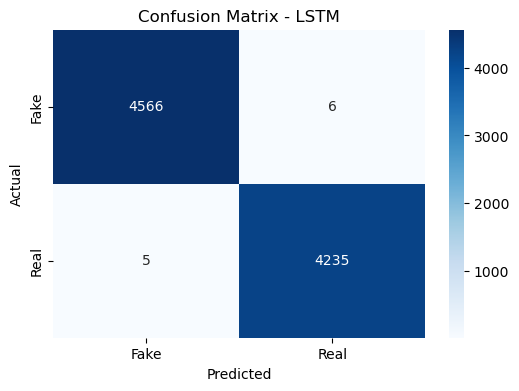

276/276 [==============================] - 1s 4ms/step


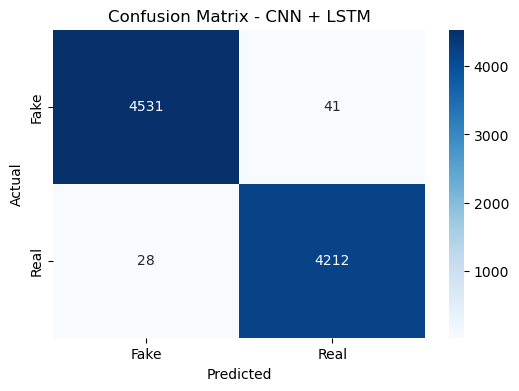

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(model, X_test, y_test, title, is_bert=False):
    y_probs = model.predict(X_test)
    y_pred = (y_probs > 0.5).astype(int)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {title}")
    plt.show()

# Confusion matrix for each model
plot_confusion_matrix(lstm_model, X_test, y_test, "LSTM")
plot_confusion_matrix(cnn_lstm_model, X_test, y_test, "CNN + LSTM")

276/276 [==============================] - 11s 40ms/step


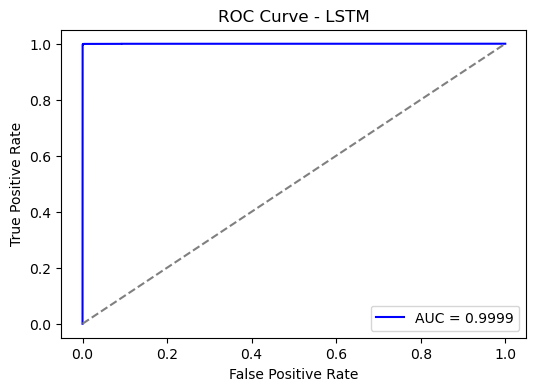

276/276 [==============================] - 1s 4ms/step


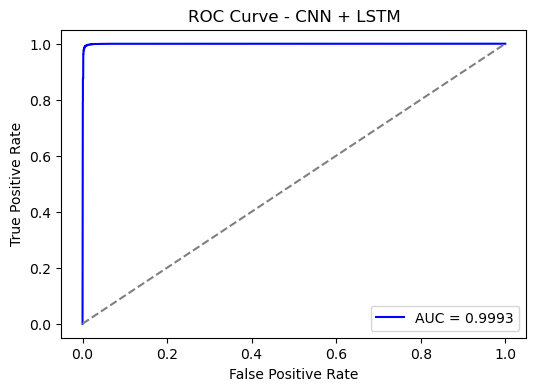

In [14]:
from sklearn.metrics import roc_curve, auc

def plot_roc_curve(model, X_test, y_test, title):
    y_probs = model.predict(X_test)  # Get probability scores
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.4f}')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {title}")
    plt.legend(loc="lower right")
    plt.show()

# ROC Curve for each model
plot_roc_curve(lstm_model, X_test, y_test, "LSTM")
plot_roc_curve(cnn_lstm_model, X_test, y_test, "CNN + LSTM")

## Based off the results above, we can see that the normal LSTM model performs slightly better than the CNN+LSTM model in terms of precision, recall and ROU-AUC score